In [1]:
import pandas as pd


df = pd.read_parquet("/Users/yavuzlule/Desktop/bsc-relish/data/processed/multilingual-test-dataset-proba.parquet")


In [2]:

df.head()

,chunk_index,chunk_text,LANGUAGE,label,word_count,word_bin,xlmroberta-base-proba
0,0.0,3 lb chicken 3/4 t anise in eggs 12 threads sa...,English,1,99,50-100,0.999999
1,0.0,"Take 12 quarts of milk warm from the cow, turn...",English,1,256,100-256,0.000002
2,1.0,70 minutes. Let cool 1 hour before serving.,English,1,8,0-20,0.999999
3,0.0,4 large granny smith apples dough:1/2 cup flou...,English,1,134,100-256,0.999999
4,0.0,4.8 lbs chicken 1/2 t salt topping: 1 c cilant...,English,1,58,50-100,0.999999


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = df.dropna(subset=["xlmroberta-base-proba", "LANGUAGE"])

df.describe()

,chunk_index,label,word_count,xlmroberta-base-proba
count,20035.000000,20123.000000,20123.000000,2.012300e+04
mean,8.719890,0.403717,197.751975,9.177913e-02
std,12.942181,0.490654,86.550312,2.870816e-01
min,0.000000,0.000000,1.000000,9.655400e-07
25%,0.000000,0.000000,115.500000,9.805515e-07
50%,3.000000,0.000000,256.000000,9.895869e-07
75%,12.000000,1.000000,256.000000,1.011769e-06
max,103.000000,1.000000,256.000000,9.999992e-01


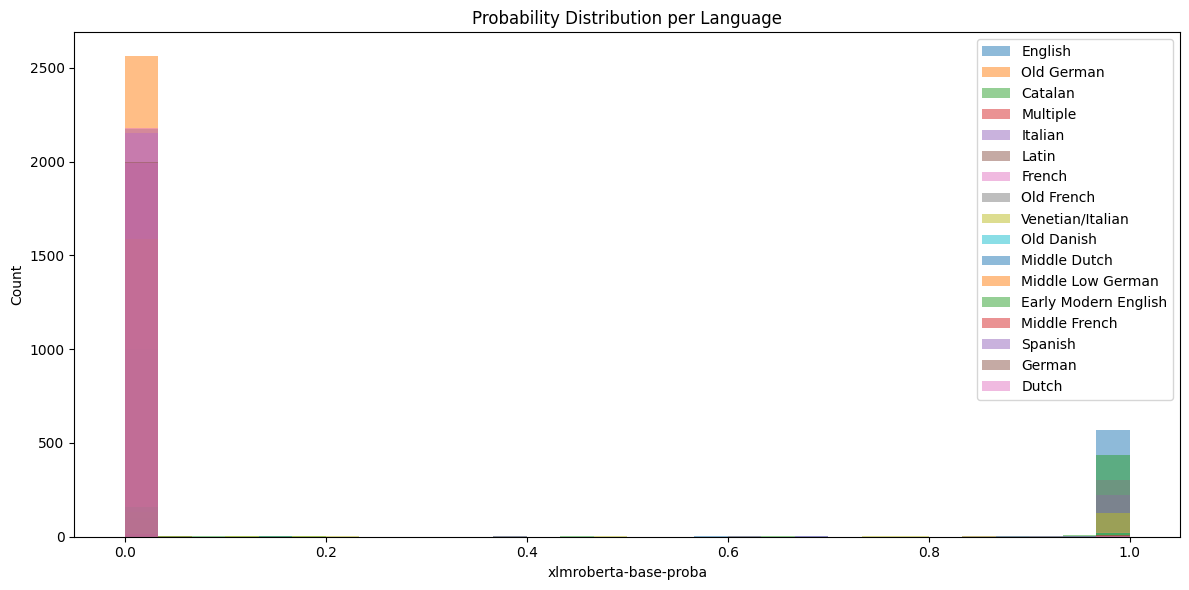

In [4]:
languages = df["LANGUAGE"].unique()

plt.figure(figsize=(12, 6))

for lang in languages:
    subset = df[df["LANGUAGE"] == lang]["xlmroberta-base-proba"]
    plt.hist(subset, bins=30, alpha=0.5, label=lang)

plt.title("Probability Distribution per Language")
plt.xlabel("xlmroberta-base-proba")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

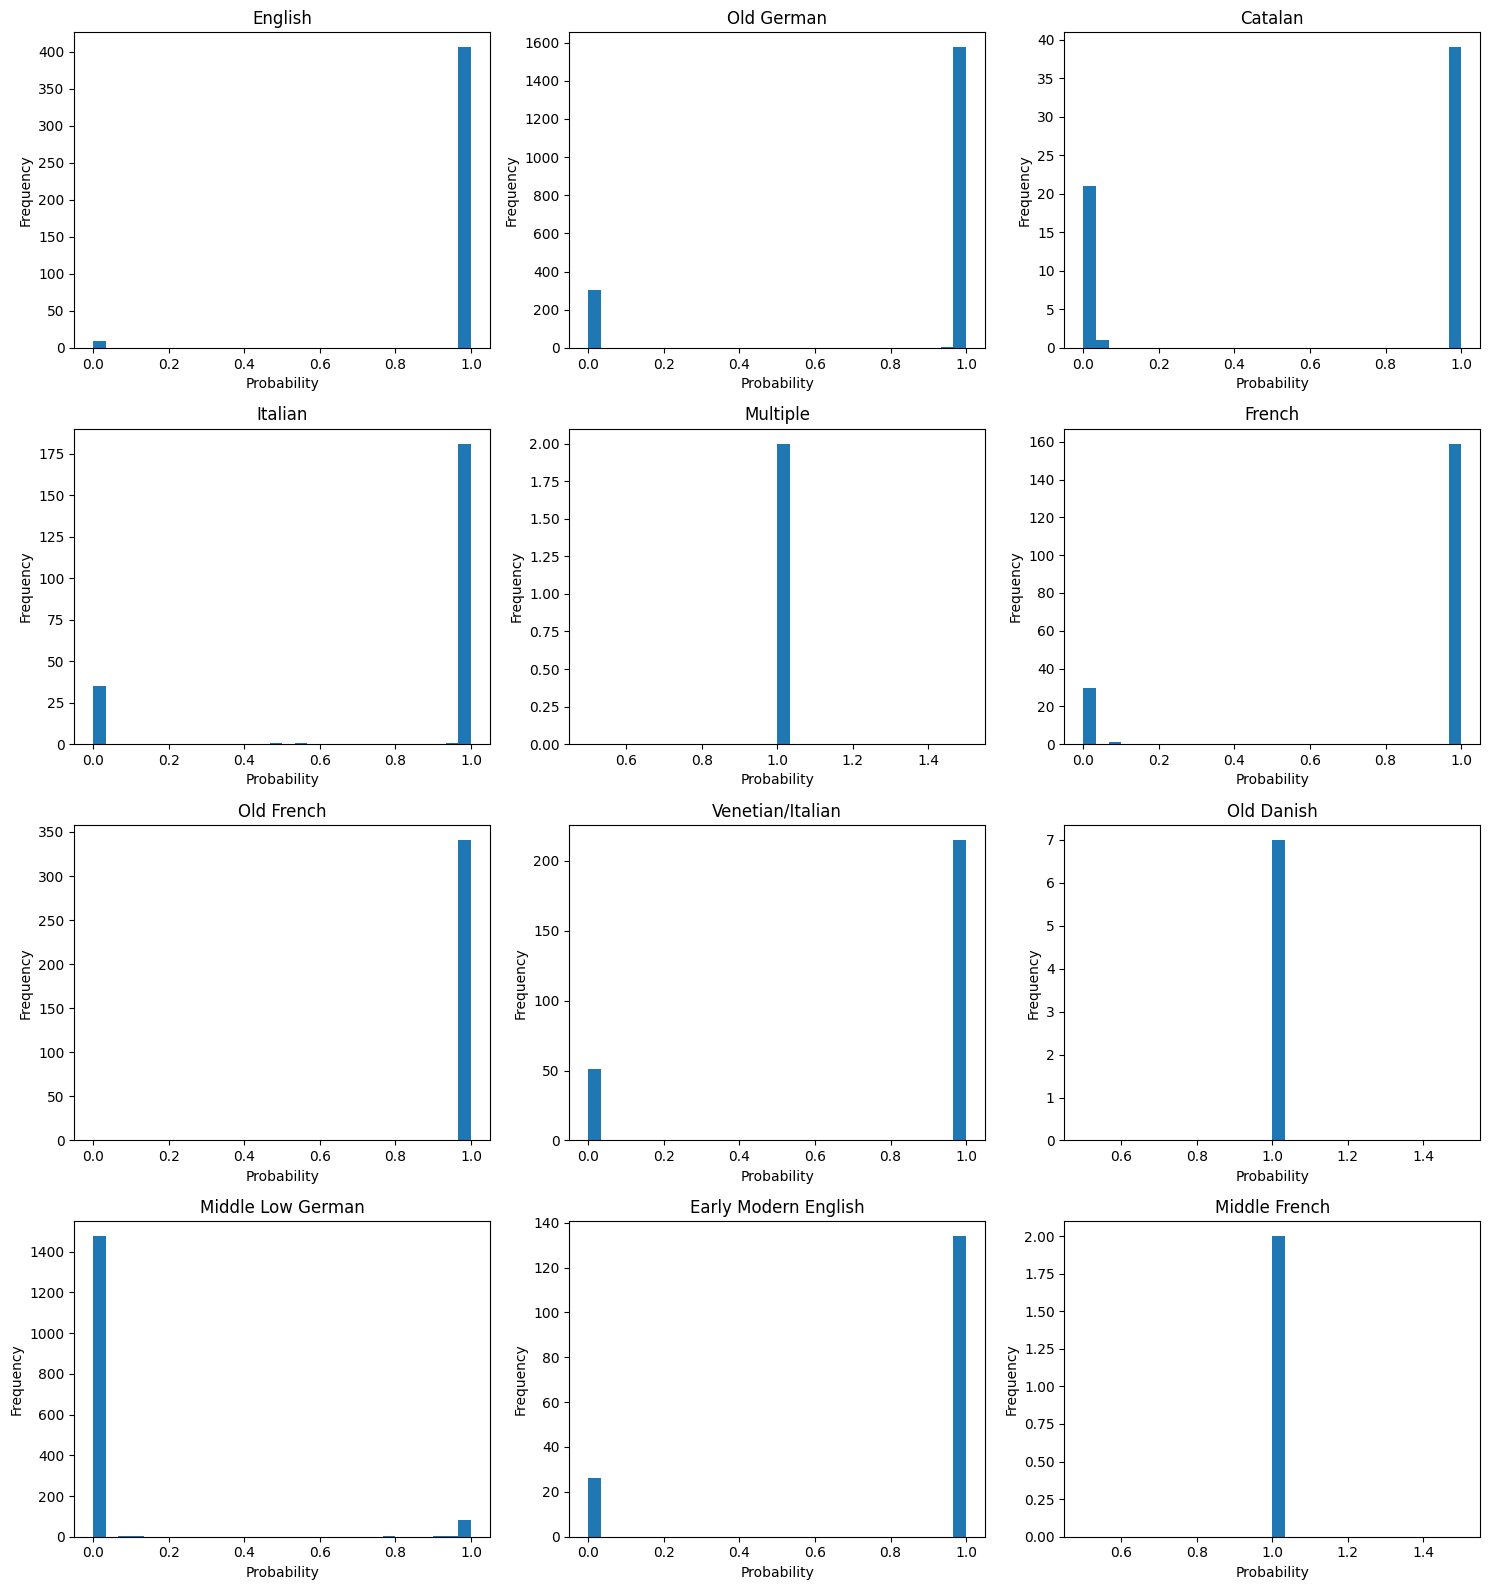

In [5]:
import matplotlib.pyplot as plt
import math

df = df.dropna(subset=["xlmroberta-base-proba", "LANGUAGE"])

languages = df["LANGUAGE"].unique()
n_langs = len(languages)

# layout (auto grid)
n_cols = 3
n_rows = math.ceil(n_langs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, lang in enumerate(languages):
    subset = df[df["LANGUAGE"] == lang]["xlmroberta-base-proba"]

    axes[i].hist(subset, bins=30)
    axes[i].set_title(lang)
    axes[i].set_xlabel("Probability")
    axes[i].set_ylabel("Frequency")

# hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [6]:
df.head()

,title,text,translation,LANGUAGE,chunk_text,chunk_id,xlmroberta-base-proba
320,"To preserve fresh figs, apples, plums, pears a...",Select them all very carefully with the stems ...,"Choose them all very carefully, stems intact, ...",English,Select them all very carefully with the stems ...,0.0,0.999992
321,To keep citron,Place them in a glass [2] vessel which is seal...,Place them in a sealed glass container and sus...,English,Place them in a glass [2] vessel which is seal...,0.0,0.999992
322,To keep mulberries,"Mulberries, in order to keep them, must be lai...","To preserve mulberries, place them in a glass ...",English,"Mulberries, in order to keep them, must be lai...",0.0,0.999992
323,To keep pot herbs,"Place selected pot herbs, not too mature, in a...","Choose young, tender pot herbs and place them ...",English,"Place selected pot herbs, not too mature, in a...",0.0,0.999992
324,To preserve sorrel or sour dock,Trim and clean [the vegetable] place them toge...,"Trim and clean the vegetables, then arrange th...",English,Trim and clean [the vegetable] place them toge...,0.0,0.999992


In [5]:
threshold = 0.5

# Filter rows above threshold
above_threshold = df[df["xlmroberta-base-proba"] > threshold]

# Count rows per language
counts_per_language = above_threshold.groupby("LANGUAGE").size()
print(counts_per_language)

LANGUAGE
Catalan                 458
Dutch                     6
Early Modern English     18
English                 581
French                   26
German                    4
Italian                 241
Latin                     5
Middle Dutch              2
Middle French             8
Middle Low German         4
Multiple                 10
Old Danish               19
Old French              304
Old German               23
Spanish                   5
Venetian/Italian        134
dtype: int64


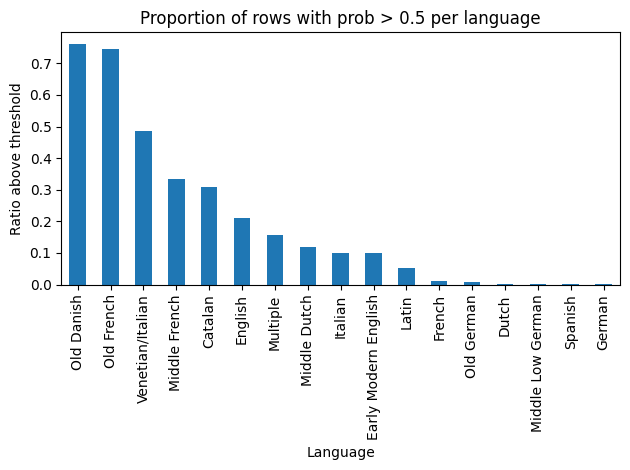

In [6]:
import matplotlib.pyplot as plt

threshold = 0.5

# Total rows per language
total_per_lang = df.groupby("LANGUAGE").size()

# Rows above threshold per language
above_per_lang = df[df["xlmroberta-base-proba"] > threshold].groupby("LANGUAGE").size()

# Align and compute ratio
ratio = (above_per_lang / total_per_lang).fillna(0)

# Plot
plt.figure()
ratio.sort_values(ascending=False).plot(kind="bar")
plt.ylabel("Ratio above threshold")
plt.xlabel("Language")
plt.title(f"Proportion of rows with prob > {threshold} per language")
plt.tight_layout()
plt.show()

In [7]:
# Filter rows
filtered_df = df[df["xlmroberta-base-proba"] < 0.5]

# Keep only unique text values
unique_texts = filtered_df["text"].drop_duplicates()

# Write to file
import textwrap
import json

MAX_WIDTH = 100  # adjust to your screen

with open("non-recipes-xlm.txt", "w", encoding="utf-8") as f:
    for i, text in enumerate(unique_texts, 1):

        f.write("=" * MAX_WIDTH + "\n")
        f.write(f"TEXT #{i}\n")
        f.write("=" * MAX_WIDTH + "\n\n")

        # Convert object to readable string
        if isinstance(text, (dict, list)):
            content = json.dumps(text, indent=2, ensure_ascii=False)
        else:
            content = str(text)

        # Wrap each paragraph separately
        wrapped = "\n".join(
            textwrap.fill(line, width=MAX_WIDTH)
            for line in content.splitlines()
        )

        f.write(wrapped + "\n\n")

KeyError: 'text'

In [21]:
book = ""

for i in range(190, 200):
    title = df.iloc[i]['title']
    text = df.iloc[i]['chunk_text']
    book += (title)
    book += (text)


print(book)

Another white sauce for boiled viandsAnother white sauce for boiled dishes contains: [1] pepper, carraway, lovage, thyme, origany, shallots, dates, honey, vinegar, broth and oil.White sauce for dainty foodTake cumin, lovage, rue seed, plums from damascus [2] soak in wine, add honey mead and vinegar, thyme and origany to taste [3].Another white sauce for appetizersIs made thus [1] pepper, thyme, cumin, celery seed, fennel, rue, mint [2], myrtle berries, raisins, raisin [167] wine, and mead to taste; stir it with a twig of satury [3].Sauce for tidbitsPepper, lovage, carraway, mint, leaves of spikenard (which the greeks call nardosachiom ) [sic!] [1] yolks, honey, mead, vinegar, broth and oil. Stir well with satury and leeks [2] and tie with roux.White sauce for tidbitsIs made thus: [1] pepper, lovage, cumin, celery seed, thyme, nuts, which soak and clean, honey, vinegar, broth and oil to be added [2].Sauce for tidbitsPepper, celery seed, carraway, satury, saffron, shallots, toasted almon

# Title Detection

In [22]:
import torch

def infer(text, tokenizer, model):
    device = "cpu"
    model.eval()
    
    encoding = tokenizer(
        text,
        return_offsets_mapping=True,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    offsets = encoding.pop("offset_mapping")[0]

    # MOVE TO CUDA
    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():

        outputs = model(**encoding)

        preds = torch.argmax(outputs.logits, dim=-1)[0]

    tokens = tokenizer.convert_ids_to_tokens(
        encoding["input_ids"][0]
    )
    print("\n===== TOKEN PREDICTIONS =====\n")

    title_tokens = []
    other_tokens = []

    current_title = []
    current_other = []

    for token, pred, (s, e) in zip(tokens, preds.cpu().numpy(), offsets):

        if s == 0 and e == 0:
            continue

        if token.startswith("▁"):
            # flush previous chunk
            if current_title:
                title_tokens.append("".join(current_title))
                current_title = []
            if current_other:
                other_tokens.append("".join(current_other))
                current_other = []

        if pred == 1:
            current_title.append(token.replace("▁", " "))
        else:
            current_other.append(token.replace("▁", " "))

    # flush last chunk
    if current_title:
        title_tokens.append("".join(current_title))
    if current_other:
        other_tokens.append("".join(current_other))


    return title_tokens, other_tokens

In [19]:
from transformers import AutoModelForTokenClassification, AutoTokenizer
from safetensors.torch import load_file

id2label = {0: "O", 1: "TITLE"}
label2id = {"O": 0, "TITLE": 1}


model = AutoModelForTokenClassification.from_pretrained(
        "xlm-roberta-base",
        num_labels=2,
        id2label=id2label,
        label2id=label2id
    )

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

state_dict = load_file("/Users/yavuzlule/Desktop/bsc-relish/results/xlmroberta-title/new/model.safetensors")

model.load_state_dict(state_dict, strict=False)


titles, rest = infer(book, tokenizer, model)

titles







Loading weights: 100%|██████████| 197/197 [00:00<00:00, 19378.00it/s]
[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



===== TOKEN PREDICTIONS =====



[]

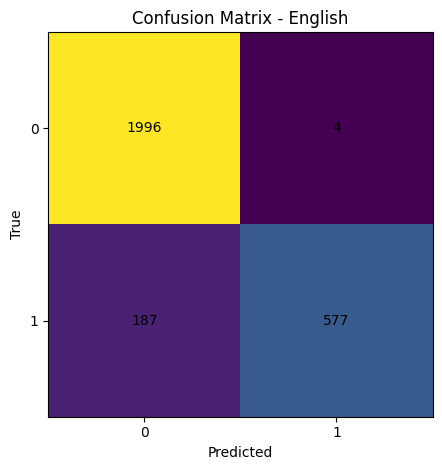

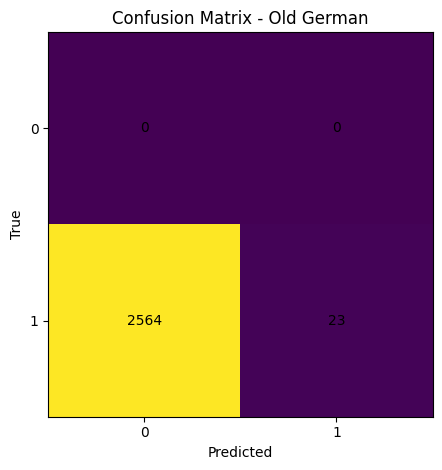

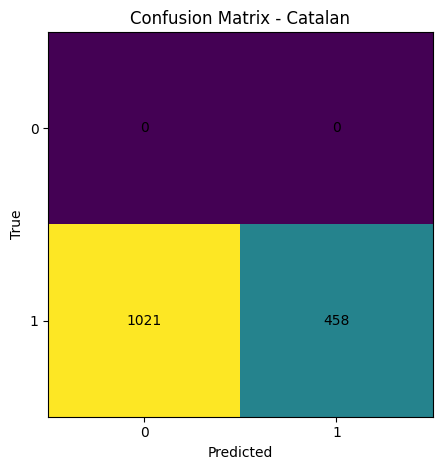

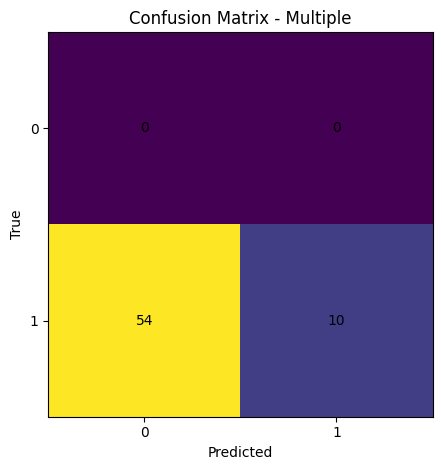

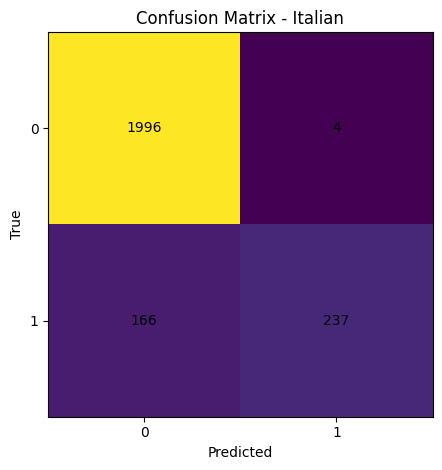

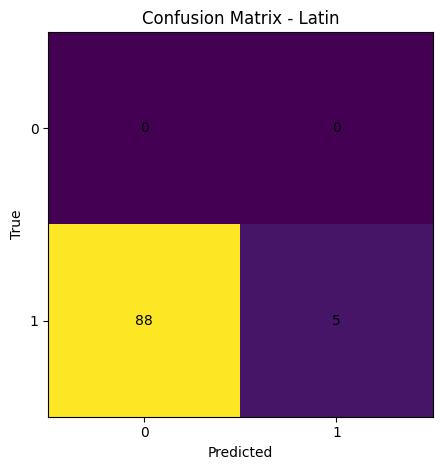

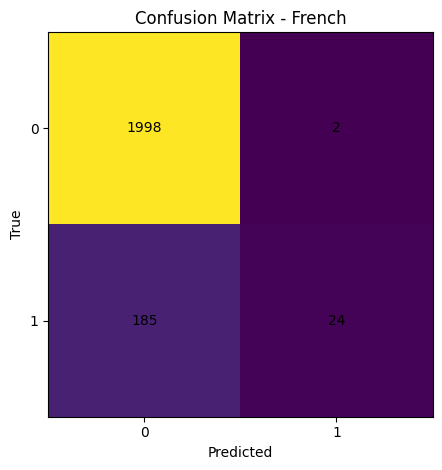

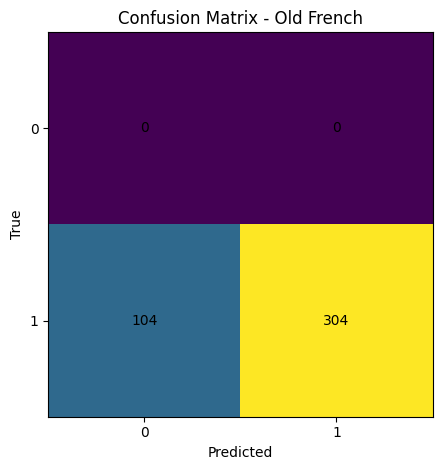

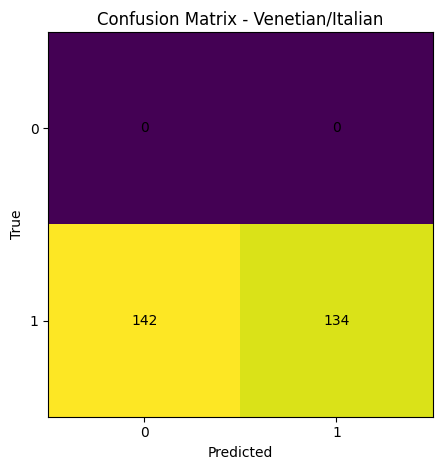

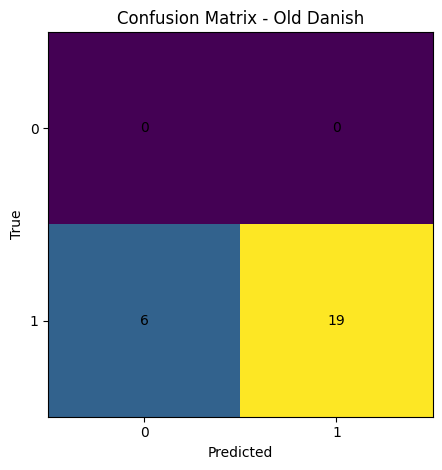

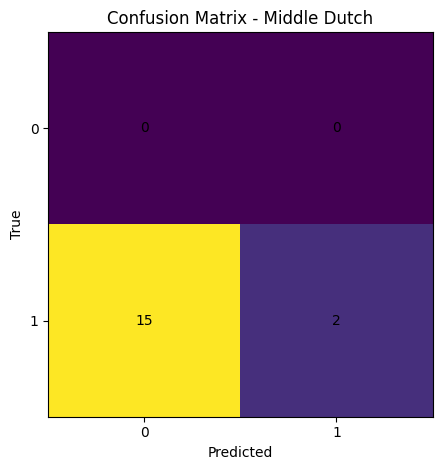

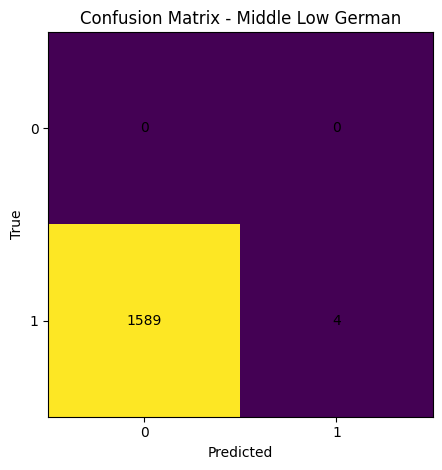

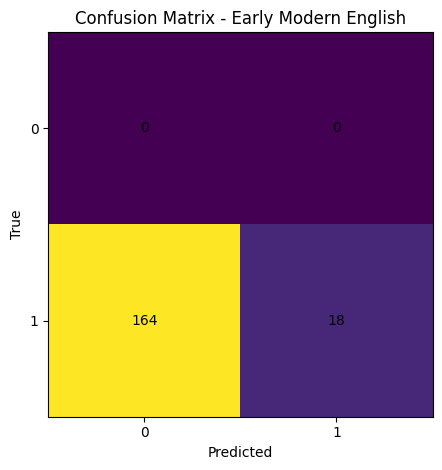

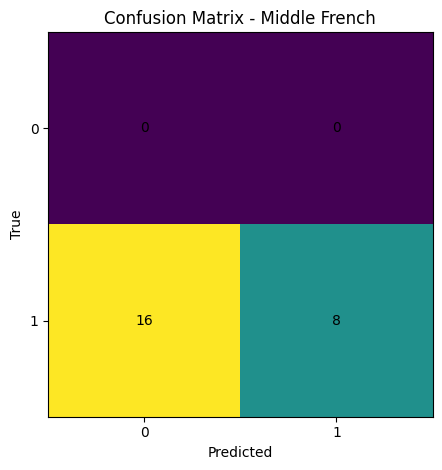

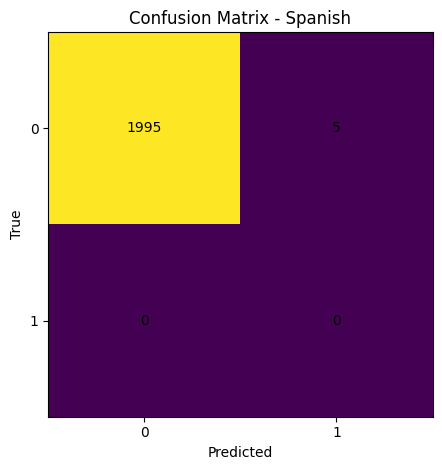

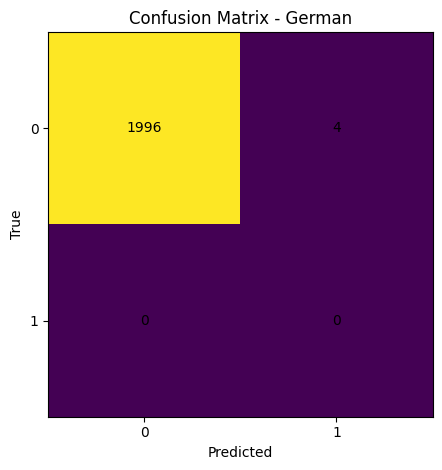

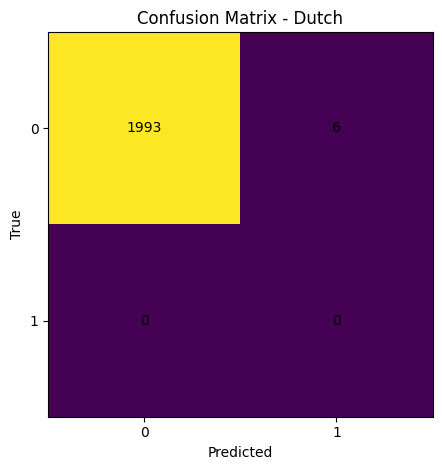

In [9]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

# Assume df already exists in environment
# If not, this code expects a DataFrame with columns:
# "LANGUAGE", "xlmroberta-proba", "label"

def plot_confusion_matrices_by_language(df, threshold=0.5):
    df = df.copy()
    
    # predicted labels from probability
    df["pred"] = (df["xlmroberta-base-proba"] >= threshold).astype(int)
    
    languages = df["LANGUAGE"].dropna().unique()
    
    for lang in languages:
        sub = df[df["LANGUAGE"] == lang]
        
        if sub.empty:
            continue
        
        y_true = sub["label"]
        y_pred = sub["pred"]
        
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        
        fig = plt.figure()
        plt.imshow(cm, interpolation='nearest')
        plt.title(f"Confusion Matrix - {lang}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        
        # annotate cells
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, str(cm[i, j]),
                         ha="center", va="center")
        
        plt.xticks([0, 1], ["0", "1"])
        plt.yticks([0, 1], ["0", "1"])
        
        plt.tight_layout()
        plt.show()

# Example usage (uncomment when df is available):
plot_confusion_matrices_by_language(df)